In [94]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from flax import nnx

X = np.linspace(0, 1, 100)[:, None]
Y = 0.8 * X**2 + 0.1 + np.random.normal(0, 0.1, size=X.shape)

def dataset(batch_size):
  while True:
    idx = np.random.choice(len(X), size=batch_size)
    yield X[idx], Y[idx]


# class Linear(nnx.Module, experimental_pytree=True):
#   def __init__(self, din: int, dout: int, *, rngs: nnx.Rngs):
#     self.w = nnx.Param(jax.random.uniform(rngs.params(), (din, dout)))
#     self.b = nnx.Param(jnp.zeros((dout,)))

#   def __call__(self, x):
#     return x @ self.w.value + self.b.value

class MLP(nnx.Module, experimental_pytree=True):
  def __init__(self, din, dhidden, dout, *, rngs: nnx.Rngs):
    self.linear1 = nnx.Linear(din, dhidden, rngs=rngs)
    self.linear2 = nnx.Linear(dhidden, dout, rngs=rngs)

  def __call__(self, x):
    x = self.linear1(x)
    x = jax.nn.relu(x)
    x = self.linear2(x)
    return x



In [95]:
model = MLP(1, 500, 1, rngs=nnx.Rngs(0))
nnx.display(model)

In [156]:
def logdenstiy_fn(model):
    y = model(X)
    return -0.5*jnp.sum((Y - y)**2)/0.5**2 - jax.tree_util.tree_reduce(lambda x, y: jnp.sum(y**2) + jnp.sum(y**2), model) # With prior


In [157]:
from probjax.inference.kernels import HMC
from probjax.inference.mcmc import MCMC

model = MLP(1, 500, 1, rngs=nnx.Rngs(0))
kernel = HMC(logdenstiy_fn)

state = kernel.init(model)
params = kernel.init_params(model, step_size=1e-3)

In [158]:
mcmc = MCMC(kernel, verbose=False)

In [159]:
state = mcmc.run(jax.random.PRNGKey(42), state, 5_000, params)

(-3.0, 3.0)

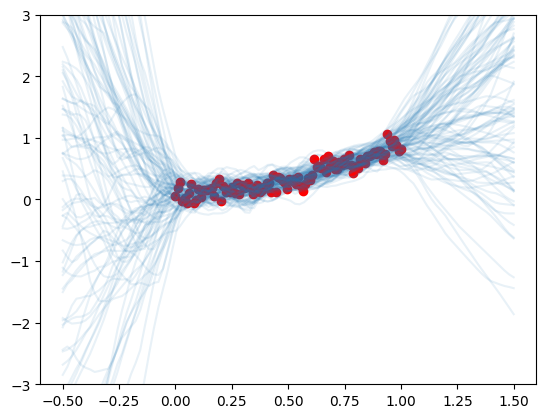

In [160]:
plt.scatter(X, Y, color="red")
for i in range(100):
    state = mcmc.run(jax.random.PRNGKey(i), state, 500, params=params)
    model = state.position
    x = np.linspace(-0.5, 1.5, 100)[:, None]
    plt.plot(x, model(x), color='C0', alpha=0.1)

plt.ylim(-3., 3.)


In [3]:
def loss_fn(model, batch):
    x, y = batch
    y_pred = model(x)
    return jnp.mean((y - y_pred)**2)

jax.jit(loss_fn)(model, next(dataset(32)))

Array(0.2529807, dtype=float32)

In [12]:

graphdef, params = nnx.split(
  MLP(din=1, dhidden=32, dout=1, rngs=nnx.Rngs(0)), nnx.Param
)

model_fn = lambda params, x: nnx.merge(graphdef, params)(x)


In [ ]:
m

In [5]:
import optax 

opt = optax.adam(1e-3)


def loss_fn(params, batch):
  x, y = batch
  model = nnx.merge(graphdef, params)
  y_pred = model(x)
  return jnp.mean((y - y_pred)**2)

@jax.jit
def update(params, opt_state, batch):
  loss, grads = jax.value_and_grad(loss_fn)(params, batch)
  updates, opt_state = opt.update(grads, opt_state)
  params = optax.apply_updates(params, updates)
  return params, opt_state, loss

In [6]:
opt_state = opt.init(params)

Step 0, Loss 19.303417205810547
Step 100, Loss 4.236952781677246
Step 200, Loss 1.1431941986083984
Step 300, Loss 0.5453251600265503
Step 400, Loss 0.1979483664035797
Step 500, Loss 0.13759037852287292
Step 600, Loss 0.12518846988677979
Step 700, Loss 0.1420639157295227
Step 800, Loss 0.1198885589838028
Step 900, Loss 0.07128889858722687
Step 1000, Loss 0.05181235447525978
Step 1100, Loss 0.052695345133543015
Step 1200, Loss 0.04940696433186531
Step 1300, Loss 0.043902624398469925
Step 1400, Loss 0.034187525510787964
Step 1500, Loss 0.03361347317695618
Step 1600, Loss 0.019904091954231262
Step 1700, Loss 0.02161809429526329
Step 1800, Loss 0.015361419878900051
Step 1900, Loss 0.0206441767513752
Step 2000, Loss 0.013505120761692524
Step 2100, Loss 0.01450725831091404
Step 2200, Loss 0.011794793419539928
Step 2300, Loss 0.012659680098295212
Step 2400, Loss 0.011653504334390163
Step 2500, Loss 0.020368296653032303
Step 2600, Loss 0.014348565600812435
Step 2700, Loss 0.012686962261795998
S

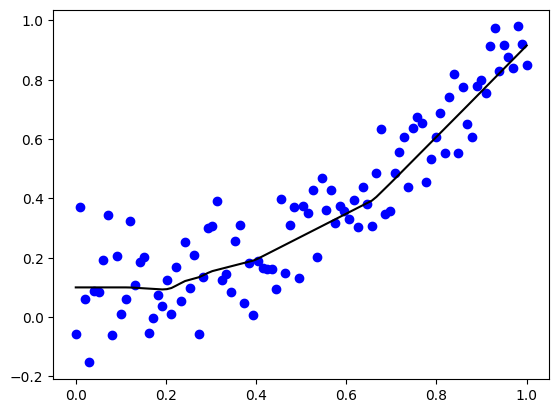

In [7]:
total_steps = 10_000
for step, batch in enumerate(dataset(32)):
  params, opt_state, loss = update(params, opt_state, batch)
  if step % 100 == 0:
    print(f'Step {step}, Loss {loss}')

  if step >= total_steps:
    break

model = nnx.merge(graphdef, params)

y_pred = model(X)

plt.scatter(X, Y, color='blue')
plt.plot(X, y_pred, color='black')
plt.show()